# Regime-Switching Time Series Analysis
## Step 1: Data Collection

This notebook implements the data collection phase of the regime-switching analysis project. We collect financial time series data from multiple asset classes spanning 2019-2022 to capture regime changes during the COVID-19 pandemic period.

### Objectives:
- Collect data from multiple asset classes (equities, fixed income, commodities, cryptocurrencies)
- Ensure daily frequency coverage from January 2019 to September 2022
- Prepare clean datasets for regime-switching analysis
- Generate comprehensive data summaries and initial visualisations

In [4]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Import our data collection module
from data_collection import collect_financial_data, save_data_summary

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

# Configure display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

### Data Collection

We collect data from the following asset classes:

**Equities:**
- S&P 500 Index (^GSPC) - daily returns
- VIX Volatility Index (^VIX) - levels

**Fixed Income:**
- 10-Year Treasury Yield (^TNX) - levels
- BAA Corporate Bond Spread (FRED) - levels

**Commodities:**
- Gold Futures (GC=F) - daily returns
- Crude Oil Futures (CL=F) - daily returns

**Cryptocurrencies:**
- Bitcoin (BTC-USD) - daily returns

In [5]:
# Collect financial data
print('Collecting financial time series data...')
data = collect_financial_data()

# Display basic information
print(f'\nData shape: {data.shape}')
print(f'Date range: {data.index.min()} to {data.index.max()}')
print(f'Number of trading days: {len(data)}')

# Display first few rows
print('\nFirst 10 observations:')
data.head(10)

Fetching FRED data...

Data shape: (943, 7)
Date range: 2019-01-03 00:00:00 to 2022-09-29 00:00:00
Number of trading days: 943

First 10 observations:


,SP500_Returns,Bitcoin_Returns,Gold_Returns,Oil_Returns,US10Y,VIX,BAA_Spread
2019-01-03,-2.475673,-2.704974,0.843095,1.181777,2.554,25.450001,2.397826
2019-01-04,3.433571,0.546722,-0.704451,1.847524,2.659,21.379999,2.391739
2019-01-07,0.701043,-1.260459,0.319646,1.167643,2.682,21.400000,2.385652
2019-01-08,0.969529,0.139112,-0.279771,2.596864,2.716,20.469999,2.379565
2019-01-09,0.409805,0.110361,0.475382,5.182808,2.728,19.980000,2.373478
2019-01-10,0.451842,-8.831367,-0.356790,0.439266,2.731,19.500000,2.367391
2019-01-11,-0.014630,0.229440,0.186816,-1.901502,2.701,18.190001,2.361304
2019-01-14,-0.525753,4.309067,0.155388,-2.093433,2.710,19.070000,2.355217
2019-01-15,1.072169,-2.033888,-0.224965,3.167694,2.711,18.600000,2.349130
2019-01-16,0.222199,0.670166,0.419843,0.383805,2.731,19.040001,2.343043


In [6]:
# Data quality assessment
print('DATA QUALITY ASSESSMENT')
print('=' * 50)

print('Missing values by column:')
missing_values = data.isnull().sum()
for col, count in missing_values.items():
    print(f'{col}: {count} ({count/len(data)*100:.2f}%)')

print('\nData types:')
print(data.dtypes)

print('\nBasic statistics:')
data.describe().round(4)

DATA QUALITY ASSESSMENT
Missing values by column:
SP500_Returns: 0 (0.00%)
Bitcoin_Returns: 0 (0.00%)
Gold_Returns: 0 (0.00%)
Oil_Returns: 0 (0.00%)
US10Y: 0 (0.00%)
VIX: 0 (0.00%)
BAA_Spread: 0 (0.00%)

Data types:
SP500_Returns      float64
Bitcoin_Returns    float64
Gold_Returns       float64
Oil_Returns        float64
US10Y              float64
VIX                float64
BAA_Spread         float64
dtype: object

Basic statistics:


,SP500_Returns,Bitcoin_Returns,Gold_Returns,Oil_Returns,US10Y,VIX,BAA_Spread
count,943.0000,943.0000,943.0000,943.0000,943.0000,943.0000,943.0000
mean,0.0498,0.2321,0.0326,-0.2663,1.7175,22.2998,2.2506
std,1.4348,4.1465,1.0211,11.4247,0.7605,8.9243,0.3669
min,-11.9841,-37.1695,-4.9787,-305.9661,0.4990,11.5400,1.7200
25%,-0.4824,-1.7010,-0.4223,-1.2150,1.1385,16.2650,2.0055
50%,0.1072,0.1245,0.0658,0.2479,1.6250,20.6700,2.1891
75%,0.7242,2.1737,0.5660,1.6230,2.2095,26.1900,2.2950
max,9.3828,18.7465,5.9477,37.6623,3.9640,82.6900,3.4700


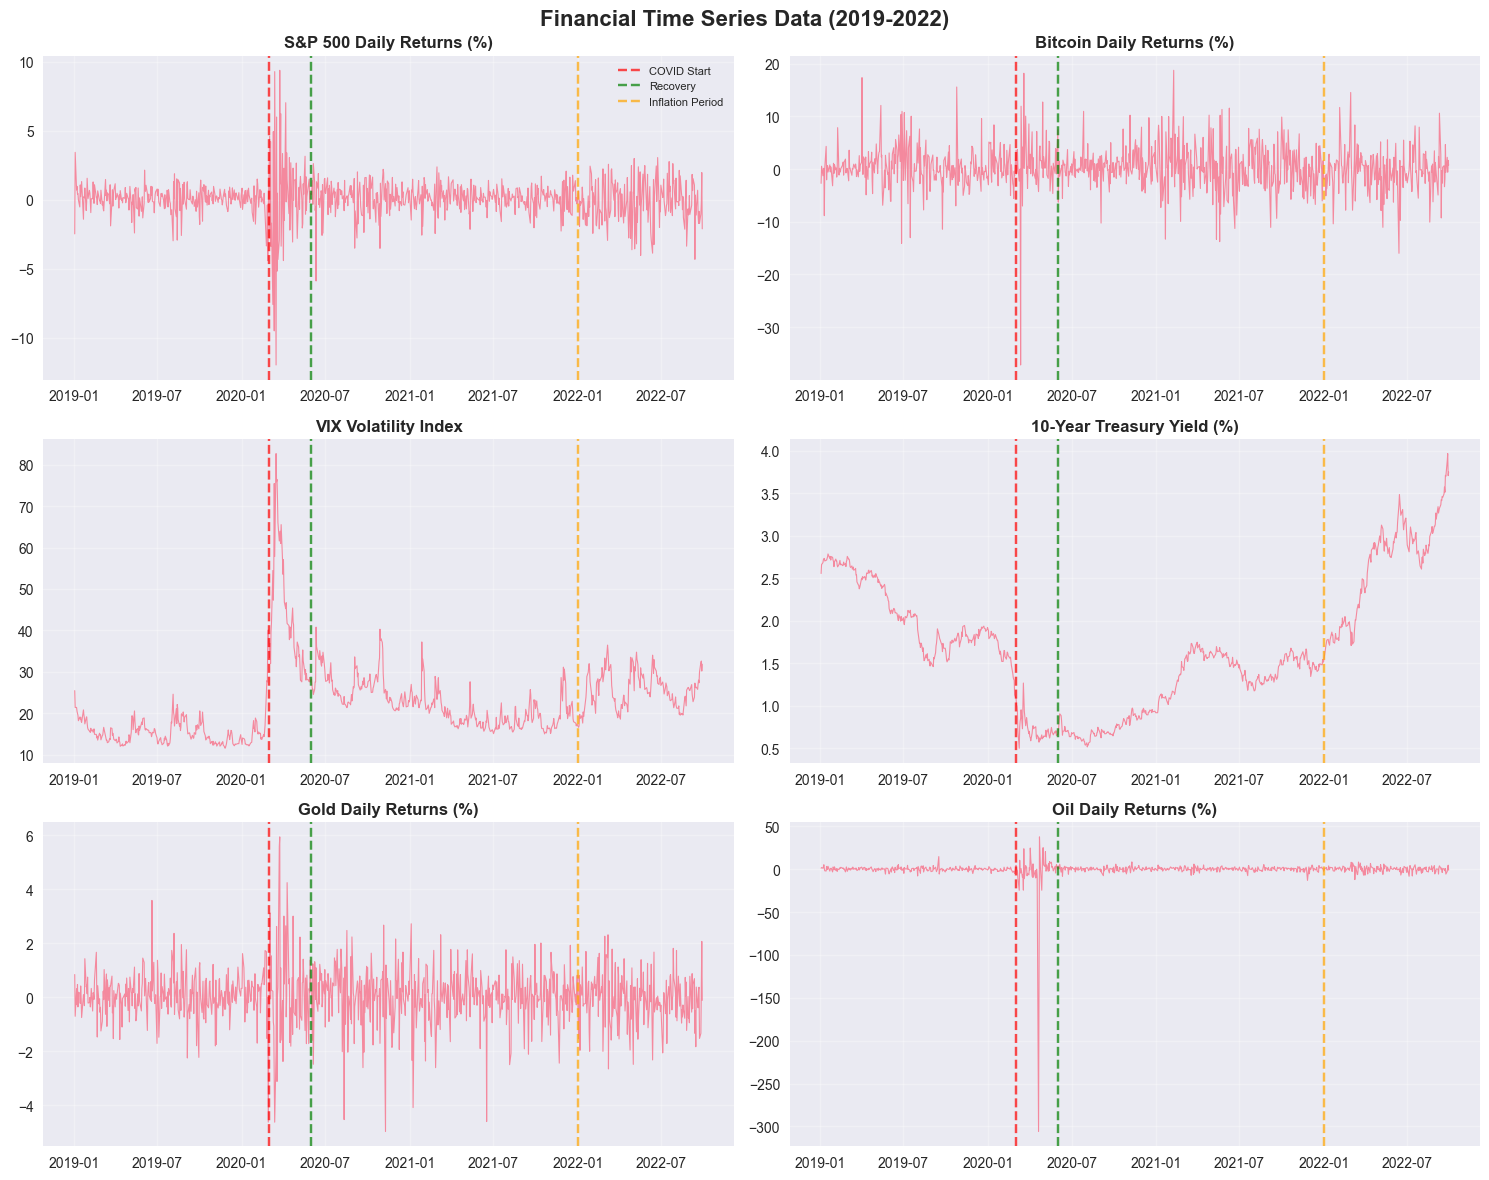

In [7]:
# Create comprehensive time series plots
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle('Financial Time Series Data (2019-2022)', fontsize=16, fontweight='bold')

# Define key COVID dates for reference
covid_start = pd.to_datetime('2020-03-01')
covid_recovery = pd.to_datetime('2020-06-01')
inflation_start = pd.to_datetime('2022-01-01')

# Plot each series
series_to_plot = ['SP500_Returns', 'Bitcoin_Returns', 'VIX', 'US10Y', 'Gold_Returns', 'Oil_Returns']
titles = ['S&P 500 Daily Returns (%)', 'Bitcoin Daily Returns (%)', 'VIX Volatility Index', 
          '10-Year Treasury Yield (%)', 'Gold Daily Returns (%)', 'Oil Daily Returns (%)']

for i, (series, title) in enumerate(zip(series_to_plot, titles)):
    row, col = i // 2, i % 2
    
    if series in data.columns:
        axes[row, col].plot(data.index, data[series], linewidth=0.8, alpha=0.8)
        axes[row, col].set_title(title, fontweight='bold')
        axes[row, col].grid(True, alpha=0.3)
        
        # Add regime change markers
        axes[row, col].axvline(covid_start, color='red', linestyle='--', alpha=0.7, label='COVID Start')
        axes[row, col].axvline(covid_recovery, color='green', linestyle='--', alpha=0.7, label='Recovery')
        axes[row, col].axvline(inflation_start, color='orange', linestyle='--', alpha=0.7, label='Inflation Period')
        
        if i == 0:  # Add legend to first subplot
            axes[row, col].legend(loc='upper right', fontsize=8)
    else:
        axes[row, col].text(0.5, 0.5, f'{series}\nNot Available', 
                           ha='center', va='center', transform=axes[row, col].transAxes)

plt.tight_layout()
plt.savefig('financial_time_series_overview.png', dpi=300, bbox_inches='tight')
plt.show()

CORRELATION ANALYSIS


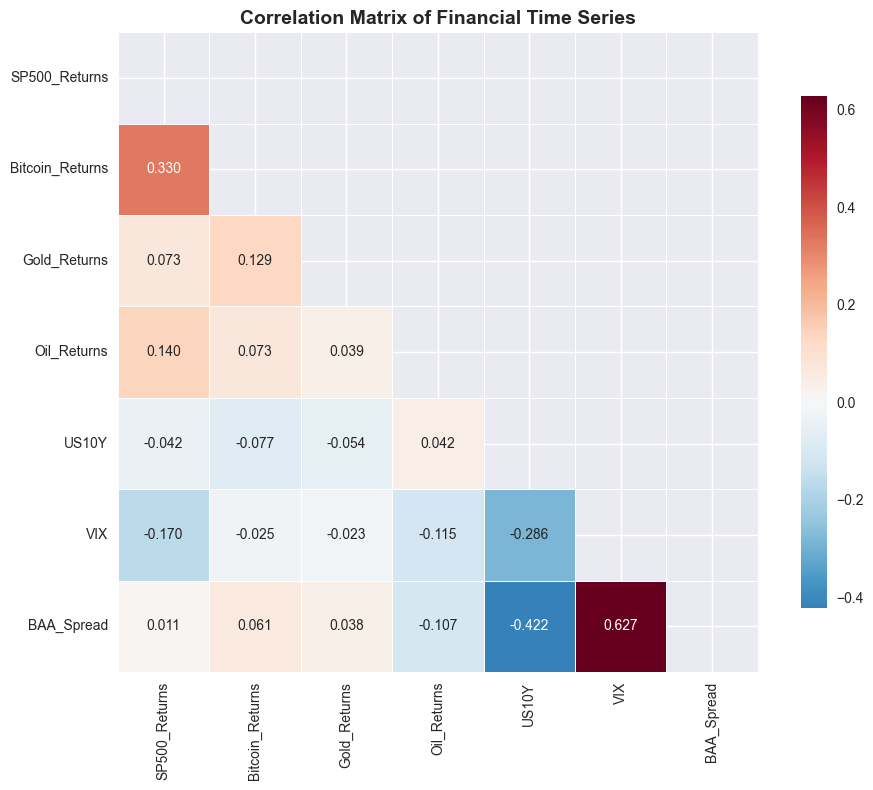


Correlation Matrix:


,SP500_Returns,Bitcoin_Returns,Gold_Returns,Oil_Returns,US10Y,VIX,BAA_Spread
SP500_Returns,1.000,0.330,0.073,0.140,-0.042,-0.170,0.011
Bitcoin_Returns,0.330,1.000,0.129,0.073,-0.077,-0.025,0.061
Gold_Returns,0.073,0.129,1.000,0.039,-0.054,-0.023,0.038
Oil_Returns,0.140,0.073,0.039,1.000,0.042,-0.115,-0.107
US10Y,-0.042,-0.077,-0.054,0.042,1.000,-0.286,-0.422
VIX,-0.170,-0.025,-0.023,-0.115,-0.286,1.000,0.627
BAA_Spread,0.011,0.061,0.038,-0.107,-0.422,0.627,1.000


In [8]:
# Correlation analysis
print('CORRELATION ANALYSIS')
print('=' * 50)

# Calculate correlation matrix
correlation_matrix = data.corr()

# Create correlation heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, fmt='.3f')
plt.title('Correlation Matrix of Financial Time Series', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print('\nCorrelation Matrix:')
correlation_matrix.round(3)

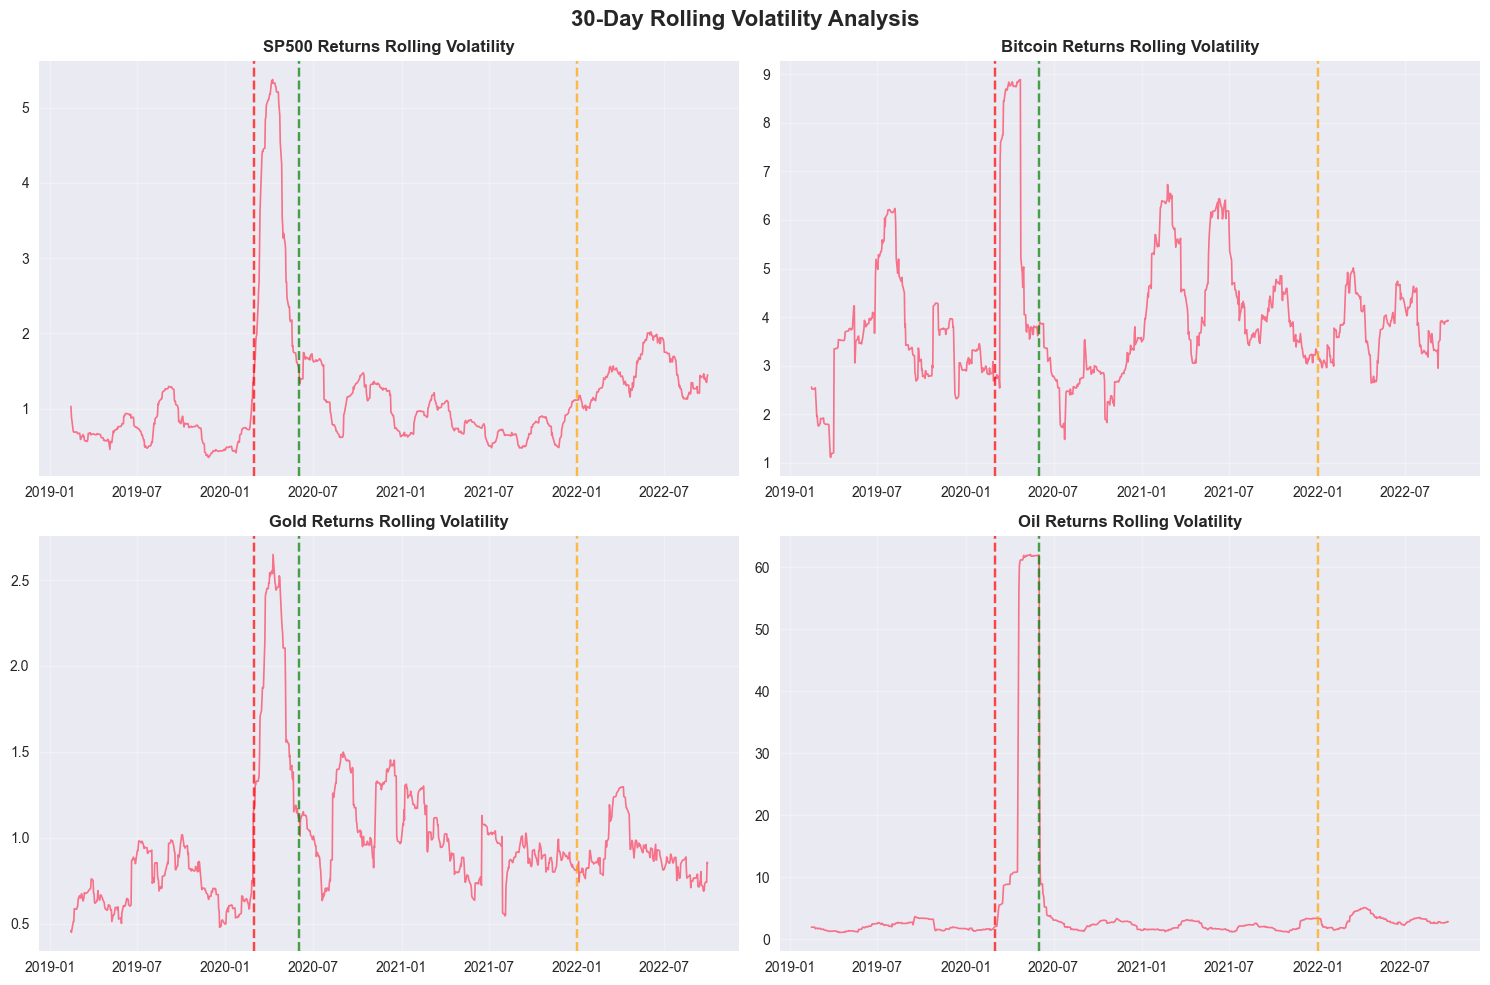

In [9]:
# Rolling volatility analysis
window = 30  # 30-day rolling window

# Calculate rolling standard deviations for return series
return_columns = [col for col in data.columns if 'Returns' in col]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f'{window}-Day Rolling Volatility Analysis', fontsize=16, fontweight='bold')

for i, col in enumerate(return_columns[:4]):
    row, col_idx = i // 2, i % 2
    
    rolling_vol = data[col].rolling(window=window).std()
    
    axes[row, col_idx].plot(rolling_vol.index, rolling_vol, linewidth=1.2)
    axes[row, col_idx].set_title(f'{col.replace("_", " ")} Rolling Volatility', fontweight='bold')
    axes[row, col_idx].grid(True, alpha=0.3)
    
    # Add regime markers
    axes[row, col_idx].axvline(covid_start, color='red', linestyle='--', alpha=0.7)
    axes[row, col_idx].axvline(covid_recovery, color='green', linestyle='--', alpha=0.7)
    axes[row, col_idx].axvline(inflation_start, color='orange', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('rolling_volatility_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
# Regime period analysis
print('REGIME PERIOD ANALYSIS')
print('=' * 50)

# Define regime periods
regimes = {
    'Pre-COVID': (data.index.min(), pd.to_datetime('2020-02-29')),
    'COVID Crisis': (pd.to_datetime('2020-03-01'), pd.to_datetime('2020-05-31')),
    'Recovery/Stimulus': (pd.to_datetime('2020-06-01'), pd.to_datetime('2021-12-31')),
    'Post-Pandemic/Inflation': (pd.to_datetime('2022-01-01'), data.index.max())
}

# Calculate statistics for each regime
regime_stats = {}

for regime_name, (start_date, end_date) in regimes.items():
    regime_data = data[(data.index >= start_date) & (data.index <= end_date)]
    
    regime_stats[regime_name] = {
        'Period': f'{start_date.strftime("%Y-%m-%d")} to {end_date.strftime("%Y-%m-%d")}',
        'Days': len(regime_data),
        'SP500_Mean': regime_data['SP500_Returns'].mean() if 'SP500_Returns' in regime_data.columns else np.nan,
        'SP500_Std': regime_data['SP500_Returns'].std() if 'SP500_Returns' in regime_data.columns else np.nan,
        'VIX_Mean': regime_data['VIX'].mean() if 'VIX' in regime_data.columns else np.nan,
        'US10Y_Mean': regime_data['US10Y'].mean() if 'US10Y' in regime_data.columns else np.nan
    }

# Convert to DataFrame for better display
regime_df = pd.DataFrame(regime_stats).T
print('Regime Statistics Summary:')
regime_df.round(4)

REGIME PERIOD ANALYSIS
Regime Statistics Summary:


,Period,Days,SP500_Mean,SP500_Std,VIX_Mean,US10Y_Mean
Pre-COVID,2019-01-03 to 2020-02-29,291,0.059736,0.86214,15.533436,2.065522
COVID Crisis,2020-03-01 to 2020-05-31,63,0.120936,3.840338,43.788572,0.732873
Recovery/Stimulus,2020-06-01 to 2021-12-31,402,0.116337,0.9746,22.212935,1.18155
Post-Pandemic/Inflation,2022-01-01 to 2022-09-29,187,-0.1327,1.502816,25.776631,2.659775


In [11]:
# Save data and generate comprehensive summary
print('SAVING DATA AND GENERATING REPORTS')
print('=' * 50)

# Save main dataset
data.to_csv('financial_time_series_2019_2022.csv')
print('✓ Main dataset saved to: financial_time_series_2019_2022.csv')

# Save regime statistics
regime_df.to_csv('regime_period_statistics.csv')
print('✓ Regime statistics saved to: regime_period_statistics.csv')

# Save correlation matrix
correlation_matrix.to_csv('correlation_matrix.csv')
print('✓ Correlation matrix saved to: correlation_matrix.csv')

# Generate comprehensive data summary
save_data_summary(data, 'comprehensive_data_summary.txt')
print('✓ Comprehensive summary saved to: comprehensive_data_summary.txt')

print('\nData collection phase completed successfully!')
print(f'Total observations: {len(data)}')
print(f'Variables collected: {len(data.columns)}')
print(f'Date range: {data.index.min().strftime("%Y-%m-%d")} to {data.index.max().strftime("%Y-%m-%d")}')

SAVING DATA AND GENERATING REPORTS
✓ Main dataset saved to: financial_time_series_2019_2022.csv
✓ Regime statistics saved to: regime_period_statistics.csv
✓ Correlation matrix saved to: correlation_matrix.csv
✓ Comprehensive summary saved to: comprehensive_data_summary.txt

Data collection phase completed successfully!
Total observations: 943
Variables collected: 7
Date range: 2019-01-03 to 2022-09-29


### Summary

This notebook has successfully completed the data collection phase of the regime-switching analysis project. Key achievements include:

1. **Multi-Asset Data Collection**: Gathered daily data from equities, fixed income, commodities, and cryptocurrencies
2. **Comprehensive Coverage**: Full coverage of the 2019-2022 period including pre-COVID, pandemic, and recovery phases
3. **Data Quality Assessment**: Thorough evaluation of missing values, data types, and statistical properties
4. **Initial Visualisations**: Time series plots revealing potential regime changes
5. **Correlation Analysis**: Understanding relationships between different asset classes
6. **Regime Period Analysis**: Preliminary identification of distinct market regimes

The data is now ready for the next phase: detailed visualisation and regime-switching model estimation.